In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Load Augmented DF

In [2]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
# Check for gaps
gt_columns = ["fips", "days_from_start", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


### Load TLGRF Benchmark Dataset

In [4]:
benchmark_TLGRF_dataset = dd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
0,1001.0,69.0,NaN,NaN,Autauga,Alabama,2020-03-30,5.142857,1.831438,2.469309,NaN
1,1001.0,70.0,NaN,NaN,Autauga,Alabama,2020-03-31,6.000000,1.960095,2.528012,NaN
2,1001.0,71.0,NaN,NaN,Autauga,Alabama,2020-04-01,6.857143,2.074070,2.550561,NaN
3,1001.0,72.0,NaN,NaN,Autauga,Alabama,2020-04-02,7.428571,2.143422,2.625703,NaN
4,1001.0,73.0,NaN,NaN,Autauga,Alabama,2020-04-03,8.285714,2.239189,2.676117,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10201,99999.0,1153.0,1456.032249,-0.030986,New York City,New York,2023-03-19,13972.285714,9.544910,NaN,9.328005
10202,99999.0,1154.0,1389.214236,-0.039535,New York City,New York,2023-03-20,13317.571429,9.496922,NaN,9.220178
10203,99999.0,1155.0,1323.021840,-0.054503,New York City,New York,2023-03-21,12458.714286,9.430264,NaN,9.048744
10204,99999.0,1156.0,1531.624962,-0.024711,New York City,New York,2023-03-22,12154.857143,9.405575,NaN,9.232600


### Define `read_csv_file` helper

In [5]:
def read_csv_file(file_path):
    # Read the CSV file into a pandas DataFrame
    try:
        GRF_df = pd.read_csv(file_path)
        return GRF_df
    except pd.errors.EmptyDataError:
        print(file_path)

### Read Time Variant GRF

In [6]:
directory = "./time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_variant_file_paths)
    pbar.update(len(time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [7]:
time_variant_GRF_results = pd.concat(time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_variant_GRF_results["date"] = pd.to_datetime(time_variant_GRF_results["date"])
time_variant_GRF_results = time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_variant_GRF_results = time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
time_variant_GRF_results = pd.merge(time_variant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0.014734,3.165860,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,-0.010749,3.007321,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,-0.008377,3.023923,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,0.003237,3.118235,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,0.018454,3.243964,3.256447
...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,-0.000178,9.543666,NaN
2649554,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,-0.000654,9.492346,NaN
2649555,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,-0.000224,9.428695,NaN
2649556,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,0.000129,9.406476,NaN


In [8]:
directory = "./shifted_W_time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
shifted_W_time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(shifted_W_time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    shifted_W_time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in shifted_W_time_variant_file_paths)
    pbar.update(len(shifted_W_time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [9]:
shifted_W_time_variant_GRF_results = pd.concat(shifted_W_time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
shifted_W_time_variant_GRF_results["date"] = pd.to_datetime(shifted_W_time_variant_GRF_results["date"])
shifted_W_time_variant_GRF_results = shifted_W_time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
shifted_W_time_variant_GRF_results = shifted_W_time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
shifted_W_time_variant_GRF_results = pd.merge(shifted_W_time_variant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(shifted_W_time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0,0.029451,3.268881,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,1,0.033634,3.318004,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,2,0.028902,3.284877,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,3,0.025175,3.271800,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,4,0.023614,3.280084,3.256447
...,...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,1103,-0.009829,9.476110,NaN
2649554,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,1104,-0.004860,9.462904,NaN
2649555,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,1105,-0.002493,9.412810,NaN
2649556,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,1106,-0.003673,9.379860,NaN


### Read Time Invariant GRF

In [10]:
directory = "./time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_invariant_file_paths)
    pbar.update(len(time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [11]:
time_invariant_GRF_results = pd.concat(time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_invariant_GRF_results["date"] = pd.to_datetime(time_invariant_GRF_results["date"])
time_invariant_GRF_results = time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_invariant_GRF_results = time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

time_invariant_GRF_results = pd.merge(time_invariant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(time_invariant_GRF_results)

,fips,date,county,state,days_from_start,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0.075195,3.589089,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,3.082565,0.064403,3.533383,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,3.082565,0.053266,3.455429,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,3.095578,0.056698,3.492464,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,3.114784,0.055530,3.503493,3.256447
...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,9.544910,0.001367,9.554478,NaN
2649554,99999,2023-03-20,New York City,New York,1154,9.496922,0.001389,9.506648,NaN
2649555,99999,2023-03-21,New York City,New York,1155,9.430264,0.001364,9.439815,NaN
2649556,99999,2023-03-22,New York City,New York,1156,9.405575,0.001365,9.415132,NaN


In [12]:
directory = "./shifted_W_time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
shifted_W_time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(shifted_W_time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    shifted_W_time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in shifted_W_time_invariant_file_paths)
    pbar.update(len(shifted_W_time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [13]:
shifted_W_time_invariant_GRF_results = pd.concat(shifted_W_time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
shifted_W_time_invariant_GRF_results["date"] = pd.to_datetime(shifted_W_time_invariant_GRF_results["date"])
shifted_W_time_invariant_GRF_results = shifted_W_time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
shifted_W_time_invariant_GRF_results = shifted_W_time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

shifted_W_time_invariant_GRF_results = pd.merge(shifted_W_time_invariant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(shifted_W_time_invariant_GRF_results)

,fips,date,county,state,days_from_start,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0,0.088425,3.681699,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,3.082565,1,0.081830,3.655375,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,3.082565,2,0.083574,3.667585,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,3.095578,3,0.075670,3.625265,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,3.114784,4,0.069887,3.603995,3.256447
...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,9.544910,1103,0.001397,9.554692,NaN
2649554,99999,2023-03-20,New York City,New York,1154,9.496922,1104,0.001370,9.506510,NaN
2649555,99999,2023-03-21,New York City,New York,1155,9.430264,1105,0.001407,9.440112,NaN
2649556,99999,2023-03-22,New York City,New York,1156,9.405575,1106,0.001395,9.415341,NaN


### Compute RMSE and MAE

In [14]:
rmse_GRF_func = lambda x: np.sqrt(np.nanmean((x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_GRF_func = lambda x: np.nanmean(np.abs(x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
#

log_20 = np.log(20 + 1.1)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= log_20]
TLGRF_df = TLGRF_df[TLGRF_df["date"] <= "2022-12-31"]


time_invariant_GRF_df = time_invariant_GRF_results[time_invariant_GRF_results["log_rolled_cases"] >= log_20]
time_invariant_GRF_df = time_invariant_GRF_df[time_invariant_GRF_df["date"] <= "2022-12-31"]

time_variant_GRF_df = time_variant_GRF_results[time_variant_GRF_results["log_rolled_cases"] >= log_20]
time_variant_GRF_df = time_variant_GRF_df[time_variant_GRF_df["date"] <= "2022-12-31"]

shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_results[shifted_W_time_invariant_GRF_results["log_rolled_cases"] >= log_20]
shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df[shifted_W_time_invariant_GRF_df["date"] <= "2022-12-31"]

shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_results[shifted_W_time_variant_GRF_results["log_rolled_cases"] >= log_20]
shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df[shifted_W_time_variant_GRF_df["date"] <= "2022-12-31"]



#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("date").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("date").apply(mae_TLGRF_func)
#Time Invariant GRF
RMSE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
#Time Variant GRF
RMSE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(mae_GRF_func)

# Shifted W Time Invariant
RMSE_shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
# Shifted W Time Variant GRF
RMSE_shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df.groupby("date").apply(mae_GRF_func)



/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: Mean of empty slice
  This is separate from the ipykernel package so we can avoid doing imports until
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.


In [15]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["MAE"] = [MAE_time_invariant_GRF_df.median(), MAE_time_variant_GRF_df.median(), MAE_TLGRF.median()]
metrics_comparison_df["RMSE"] = [RMSE_time_invariant_GRF_df.median(), RMSE_time_variant_GRF_df.median(), RMSE_TLGRF.median()]
metrics_comparison_df.index = ["Time Invariant GRF", "Time Variant GRF", "TLGRF"]
metrics_comparison_df

,MAE,RMSE
Time Invariant GRF,0.218432,0.291404
Time Variant GRF,0.206196,0.277697
TLGRF,0.126516,0.194870


In [16]:
[RMSE_time_invariant_GRF_df.median(), RMSE_TLGRF.median()]

[0.29140357390349897, 0.19487029059240693]

In [17]:
[MAE_time_invariant_GRF_df.median(), MAE_TLGRF.median()]

[0.21843200300015087, 0.1265164490059572]

In [18]:
days_to_date_df = time_variant_GRF_results[["days_from_start","date"]]
days_to_date_df.drop_duplicates(inplace=True)
days_to_date_df = days_to_date_df.sort_values(by="date")

date0 = days_to_date_df["date"].min() - pd.Timedelta(days=days_to_date_df["days_from_start"].min())
date0 = date0.date()
missing_days_df = pd.DataFrame({'days_from_start': range(0, days_to_date_df["days_from_start"].max()),
                                'date': pd.date_range(start=date0, periods=days_to_date_df["days_from_start"].max())})
#date0, days_to_date_df["date"].min(), pd.Timedelta(days=days_to_date_df["days_from_start"].min())
missing_days_df

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,days_from_start,date
0,0,2020-01-21
1,1,2020-01-22
2,2,2020-01-23
3,3,2020-01-24
4,4,2020-01-25
...,...,...
1152,1152,2023-03-18
1153,1153,2023-03-19
1154,1154,2023-03-20
1155,1155,2023-03-21


In [19]:
days_to_date_df[days_to_date_df["date"]=="2021-09-12"]

,days_from_start,date
514,600,2021-09-12


### Plot TLGRF vs GRF

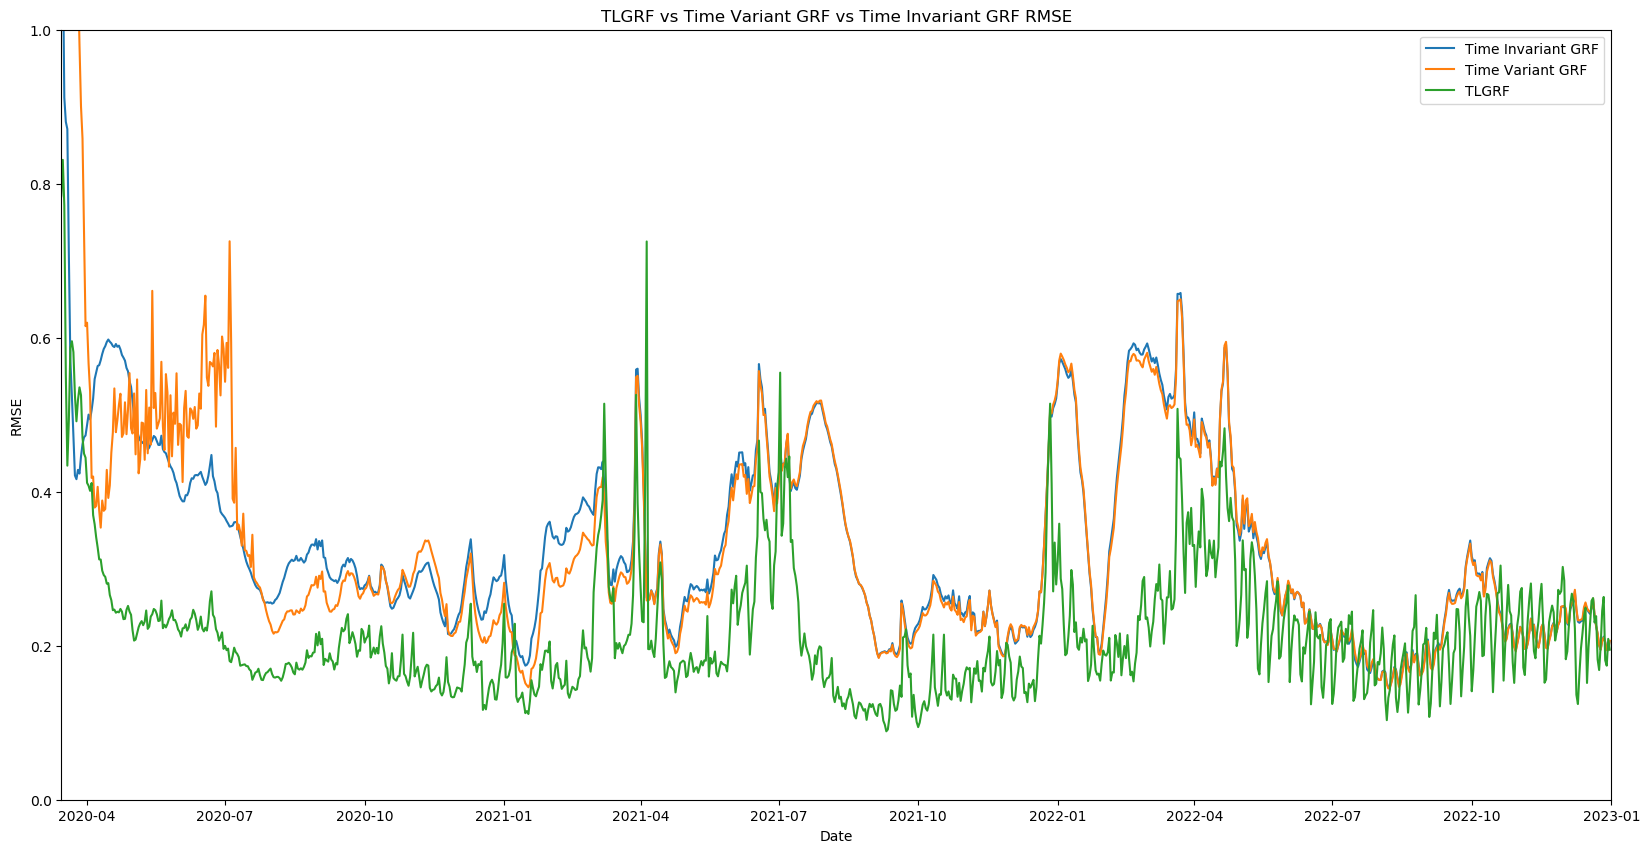

In [21]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["rmse"], label="tcv")
#plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(RMSE_time_invariant_GRF_df, label="Time Invariant GRF")
plt.plot(RMSE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Time Variant GRF vs Time Invariant GRF RMSE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("variant_and_invariant_grf_tlgrf_rmse.png")
plt.show()


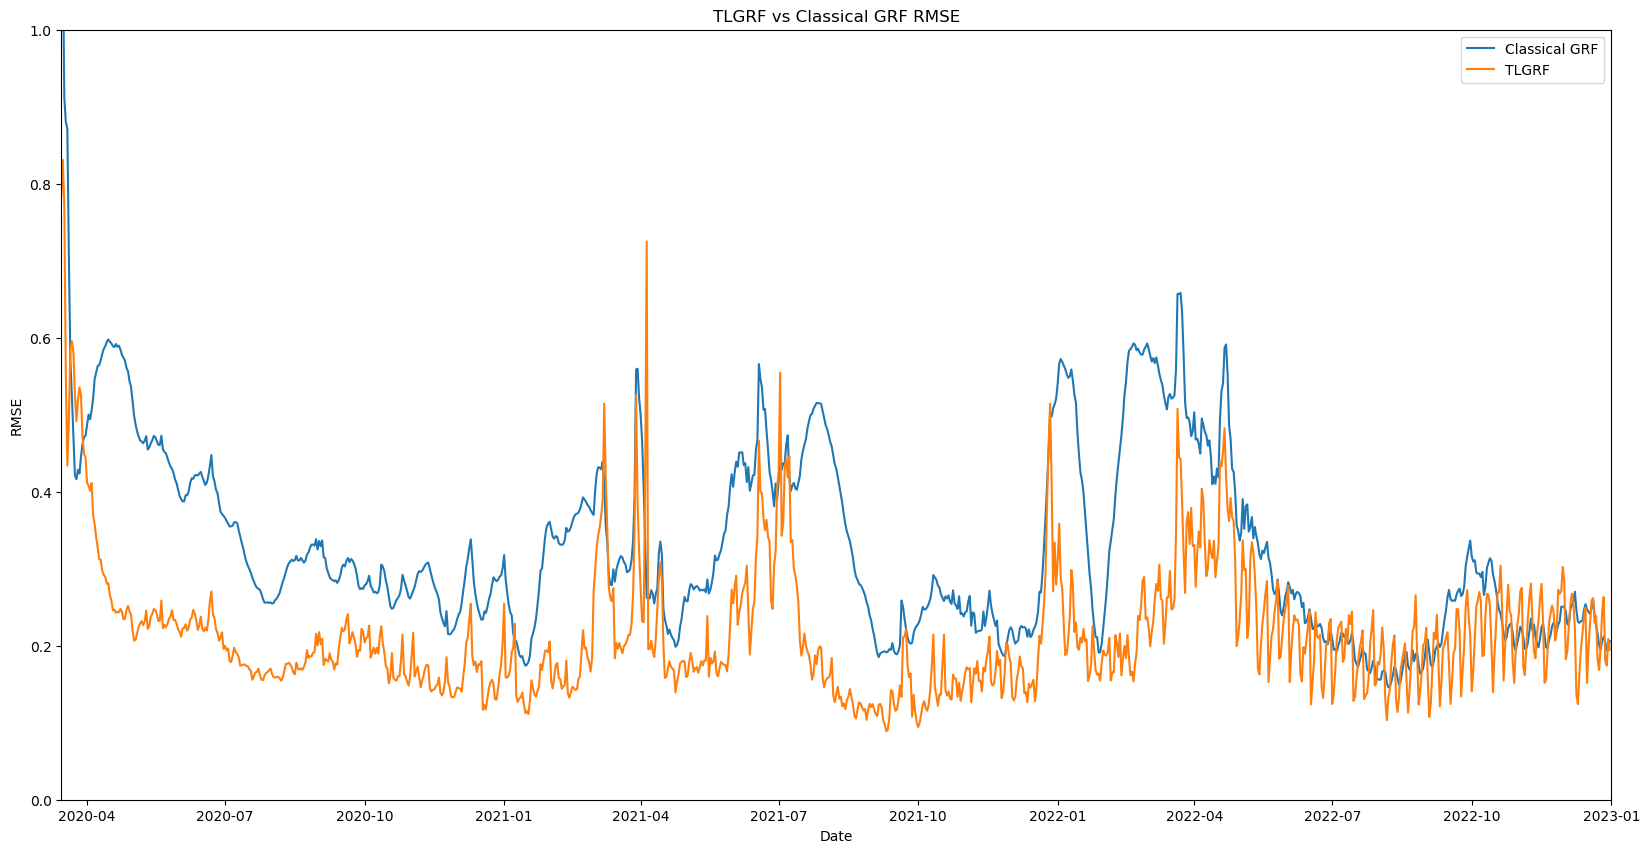

In [22]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["rmse"], label="tcv")
#plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(RMSE_time_invariant_GRF_df, label="Classical GRF")
#plt.plot(RMSE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Classical GRF RMSE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("updated_grf_tlgrf_rmse.png")
plt.show()


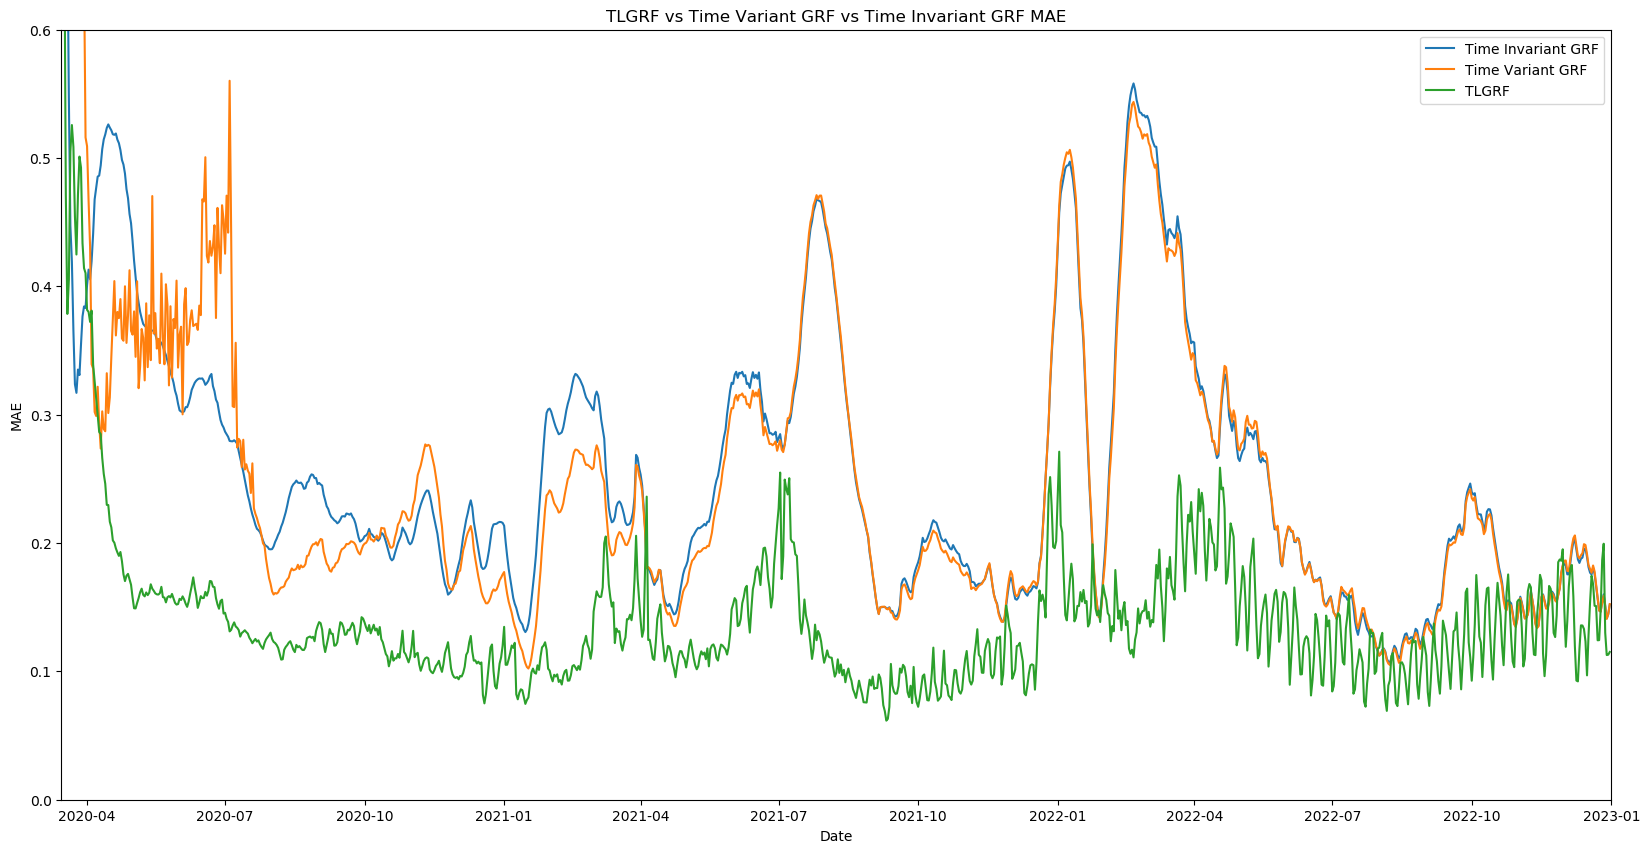

In [23]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_invariant_GRF_df, label="Time Invariant GRF")
plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Time Variant GRF vs Time Invariant GRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("variant_and_invariant_grf_tlgrf_mae.png")

plt.show()

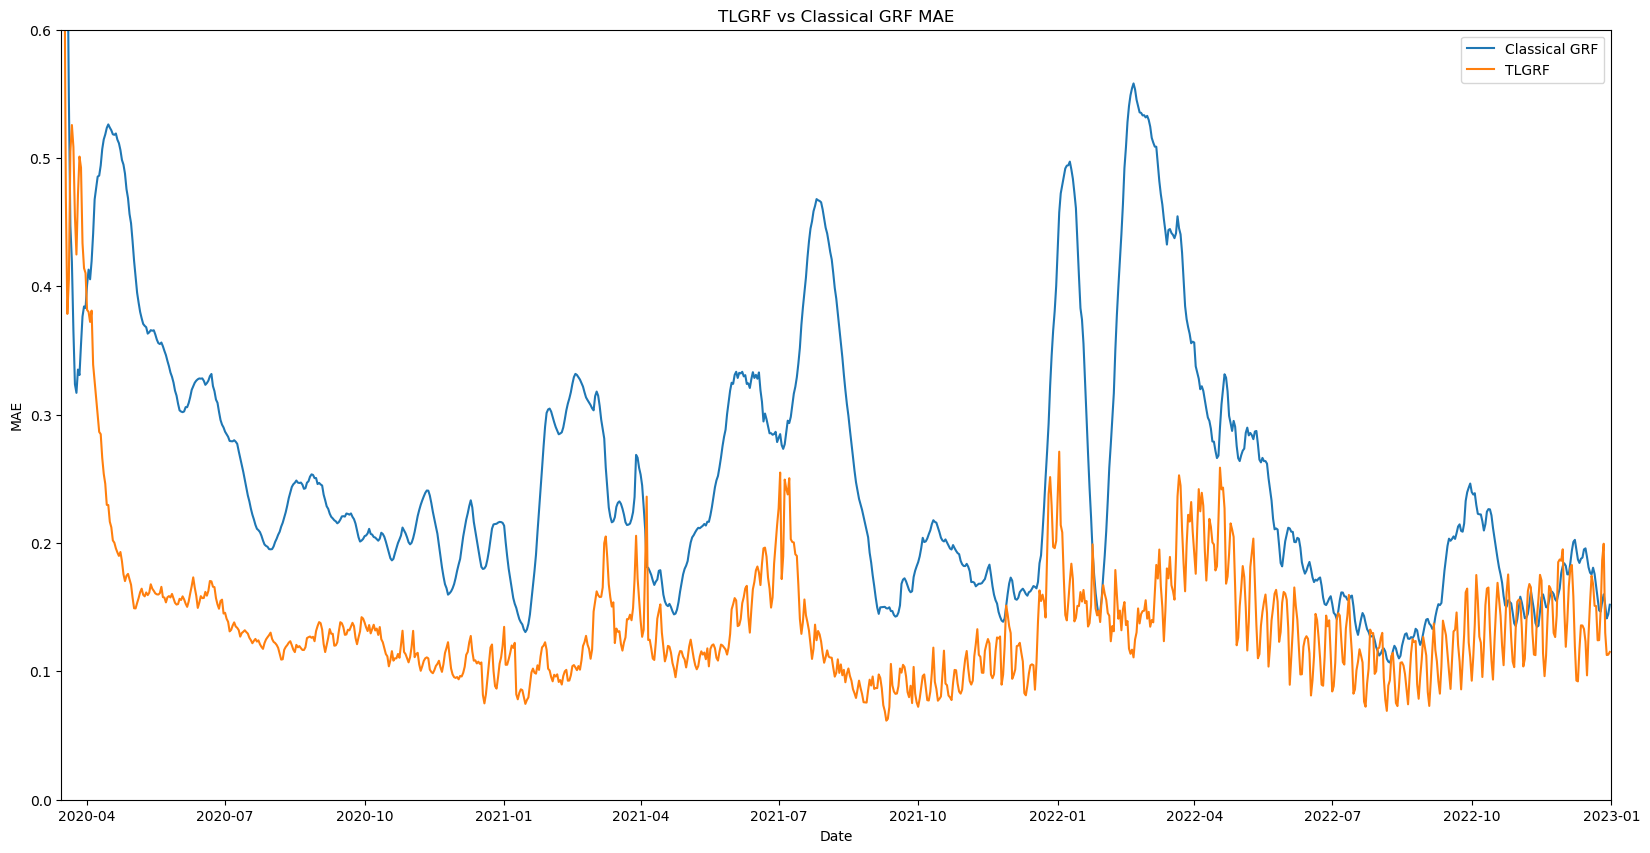

In [24]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_invariant_GRF_df, label="Classical GRF")
#plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Classical GRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("updated_grf_tlgrf_mae.png")

plt.show()

In [25]:
def check_gt(df1, df2):
    #print(df1.shape)
    #print(df2.shape)
    check_df = pd.merge(df1, df2, on=["fips","days_from_start"], how="inner")
    check_x = np.sum(check_df["log_rolled_cases_x"] - check_df["log_rolled_cases_y"])
    check_y = np.sum(check_df["shifted_log_rolled_cases_x"] - check_df["shifted_log_rolled_cases_y"])
    return (check_df, check_x, check_y)

In [26]:
RMSE_TLGRF.to_csv("RMSE_TLGRF.csv")
MAE_TLGRF.to_csv("MAE_TLGRF.csv")
RMSE_time_invariant_GRF_df.to_csv("RMSE_time_invariant_GRF_df.csv")
MAE_time_invariant_GRF_df.to_csv("MAE_time_invariant_GRF_df.csv")
RMSE_time_variant_GRF_df.to_csv("RMSE_time_variant_GRF_df.csv")
MAE_time_variant_GRF_df.to_csv("MAE_time_variant_GRF_df.csv")

RMSE_shifted_W_time_invariant_GRF_df.to_csv("RMSE_shifted_W_time_invariant_GRF_df.csv")
MAE_shifted_W_time_invariant_GRF_df.to_csv("MAE_shifted_W_time_invariant_GRF_df.csv")
RMSE_shifted_W_time_variant_GRF_df.to_csv("RMSE_shifted_W_time_variant_GRF_df.csv")
MAE_shifted_W_time_variant_GRF_df.to_csv("MAE_shifted_W_time_variant_GRF_df.csv")


### For Presentation

In [27]:
presentation_folder = "Presentation Plots"

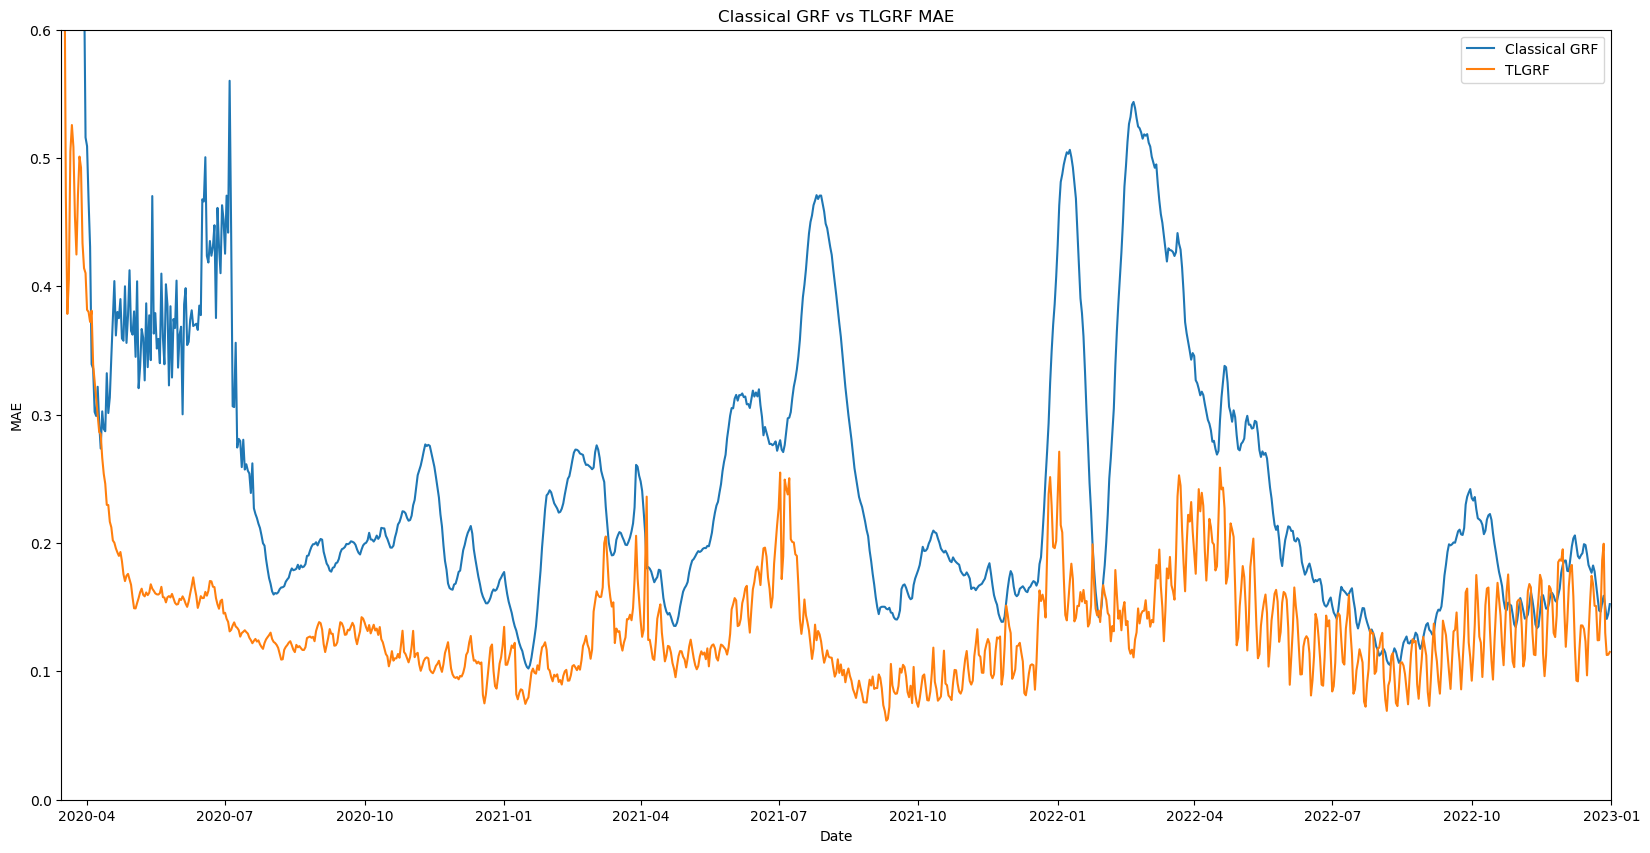

In [28]:
double_fig_path = os.path.join(presentation_folder, "presentation_classical_vs_TLGRF.png")

plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_variant_GRF_df, label="Classical GRF")
#plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Classical GRF vs TLGRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig(double_fig_path)

plt.show()

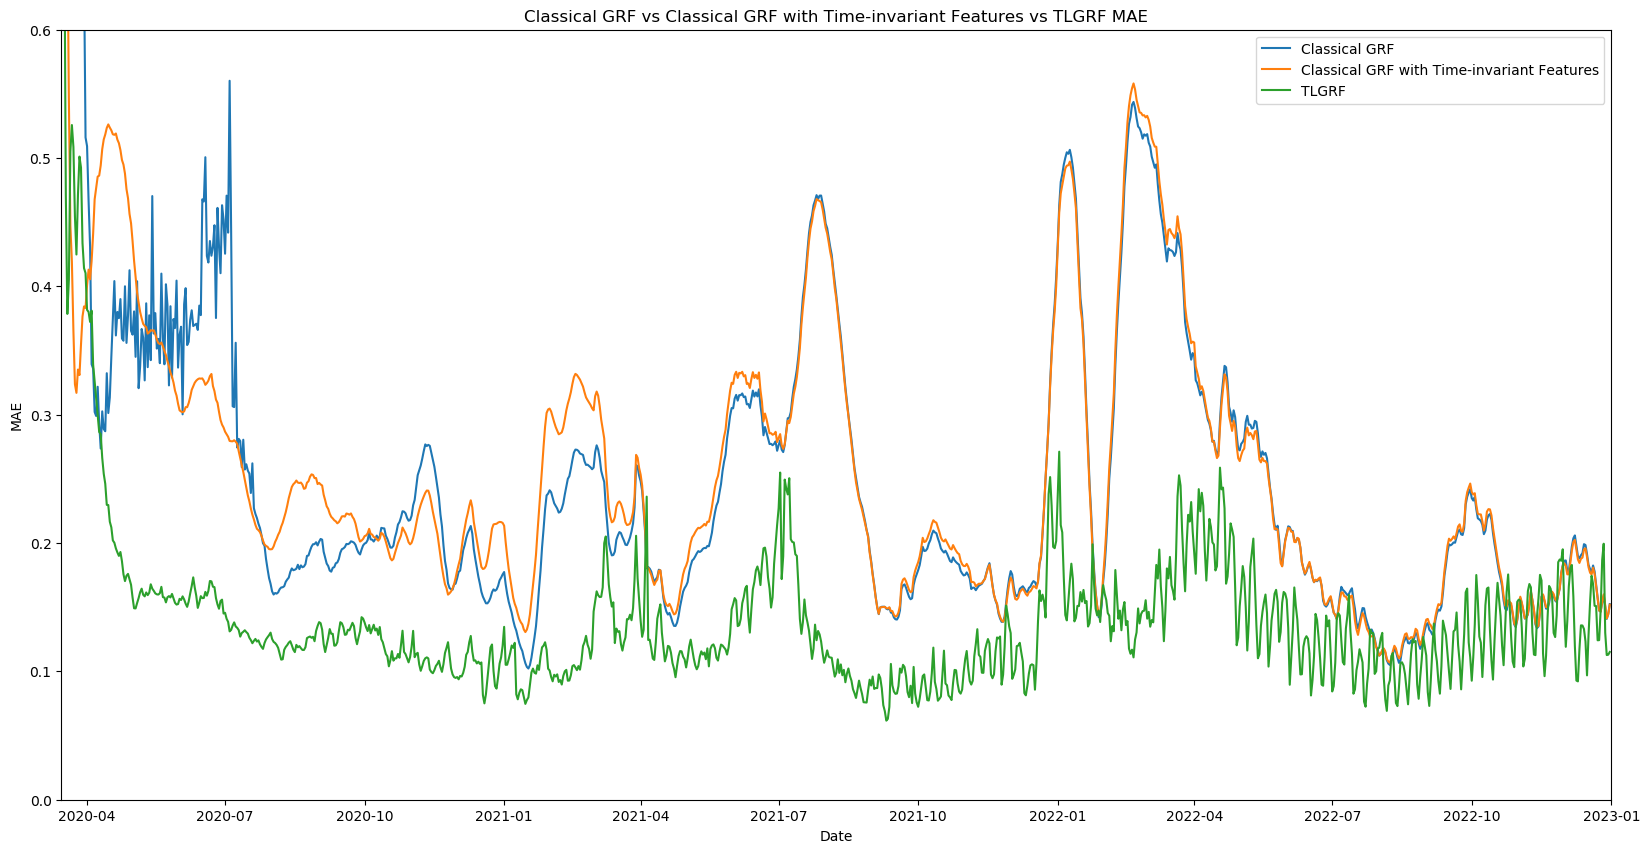

In [29]:
triple_fig_path = os.path.join(presentation_folder, "presentation_classical_invariant_vs_TLGRF.png")

plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_variant_GRF_df, label="Classical GRF")
plt.plot(MAE_time_invariant_GRF_df, label="Classical GRF with Time-invariant Features")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Classical GRF vs Classical GRF with Time-invariant Features vs TLGRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig(triple_fig_path)

plt.show()